# Final round 02: iterative pseudo-labelling of scraped reviews with fine-tuned Indonesian RoBERTa (confidence > 0.85)

In [ ]:
!nvidia-smi

Thu Oct  5 01:09:18 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.156.00   Driver Version: 450.156.00   CUDA Version: 11.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      On   | 00000000:07:00.0 Off |                    0 |
| N/A   28C    P0    61W / 400W |  40204MiB / 40537MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
|   1  A100-SXM4-40GB      On   | 00000000:0F:00.0 Off |                    0 |
| N/A   

In [ ]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '6'

## Helper

In [ ]:
def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    return 2 * (precision * recall) / (precision + recall + K.epsilon())

start = 0

def plot_loss(history_dict):
    key1 = list(history_dict.keys())[0]
    key2 = list(history_dict.keys())[2]
    loss_values = history_dict[key1][start:]
    val_loss_values = history_dict[key2][start:]
    plt.plot(loss_values, "b-", label=key1)
    plt.plot(val_loss_values, "r--", label=key2)
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()
    print(key1, ": ", history_dict[key1][-1], key2, ": ", history_dict[key2][-1])


def plot_metric(history_dict):
    key1 = list(history_dict.keys())[1]
    key2 = list(history_dict.keys())[3]
    metric_values = history_dict[key1][start:]
    val_metric_values = history_dict[key2][start:]
    plt.plot(metric_values, "b-", label=key1)
    plt.plot(val_metric_values, "r--", label=key2)
    plt.title("Training vs Validation Metric")
    plt.legend()
    plt.show()
    print(key1, ": ", history_dict[key1][-1], key2, ": ", history_dict[key2][-1])

## Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, TFBertModel, TrainingArguments, Trainer, \
    AutoModelForSequenceClassification, EarlyStoppingCallback
import evaluate
import torch

import tensorflow as tf
import keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense

print(torch.cuda.is_available())
print(tf.config.list_physical_devices('GPU'))

/usr/local/lib/python3.8/dist-packages/torchaudio/backend/utils.py:53: UserWarning: "sox" backend is being deprecated. The default backend will be changed to "sox_io" backend in 0.8.0 and "sox" backend will be removed in 0.9.0. Please migrate to "sox_io" backend. Please refer to https://github.com/pytorch/audio/issues/903 for the detail.
  warnings.warn(


True
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
jne = pd.read_csv("scrape_dataset/raw/ReviewJNEIndonesia.csv")
jnt = pd.read_csv("scrape_dataset/raw/ReviewJ&TIndonesia.csv")
jne["expedition"] = "JNE"
jnt["expedition"] = "J&T"
df = pd.concat([jne, jnt])
df.drop(["Unnamed: 0"], axis=1, inplace=True)

print("JNE shape:", jne.shape, "J&T shape:", jnt.shape, "Combined shape:", df.shape)
print(df.columns)
df.head()

JNE shape: (61529, 15) J&T shape: (69936, 15) Combined shape: (131465, 14)
Index(['source', 'review_id', 'user_name', 'review_title',
       'review_description', 'rating', 'thumbs_up', 'review_date',
       'developer_response', 'developer_response_date', 'appVersion',
       'laguage_code', 'country_code', 'expedition'],
      dtype='object')


,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition
0,Google Play,3899fc94-7b59-45ba-ab06-6ad26ffb71d1,Ahmad Firdaus,NaN,Untuk pengiriman ke pandeglang sangat lambat. ...,3,0,2023-10-03 07:57:08,NaN,NaN,NaN,id,id,JNE
1,Google Play,afee4dfd-d2d1-4e5f-a9d8-f9f1f0e1ac01,marifat dieyah,NaN,buruk sekali pengiriman JNE ini . lemot pol .,1,0,2023-10-03 07:17:46,NaN,NaN,NaN,id,id,JNE
2,Google Play,8f2ab06b-4f0d-4a82-a6c2-4dba644472ef,nur sela,NaN,paket muter muter dan gak jalan jalan cs bilan...,1,0,2023-10-03 06:14:08,NaN,NaN,NaN,id,id,JNE
3,Google Play,6dc71aee-60c3-4955-8f7a-9e96962bda12,robby sobara,NaN,"Expedisi paling buruk, pengiriman dari indrama...",1,0,2023-10-03 05:15:55,NaN,NaN,1.2.6,id,id,JNE
4,Google Play,26fdb423-103f-41b1-bd8e-825ea3e8ddf0,William Aditya,NaN,Nobody at office. Chat cs jne infonya kantor t...,1,0,2023-10-03 04:42:36,NaN,NaN,2.3.9,id,id,JNE


In [ ]:
rating_5_and_1_df = df[(df["rating"] == 5) | (df["rating"] == 1)]
print("Rating 5 and 1 shape:", rating_5_and_1_df.shape)
rating_5_and_1_df.head()

Rating 5 and 1 shape: (110177, 14)


,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition
1,Google Play,afee4dfd-d2d1-4e5f-a9d8-f9f1f0e1ac01,marifat dieyah,NaN,buruk sekali pengiriman JNE ini . lemot pol .,1,0,2023-10-03 07:17:46,NaN,NaN,NaN,id,id,JNE
2,Google Play,8f2ab06b-4f0d-4a82-a6c2-4dba644472ef,nur sela,NaN,paket muter muter dan gak jalan jalan cs bilan...,1,0,2023-10-03 06:14:08,NaN,NaN,NaN,id,id,JNE
3,Google Play,6dc71aee-60c3-4955-8f7a-9e96962bda12,robby sobara,NaN,"Expedisi paling buruk, pengiriman dari indrama...",1,0,2023-10-03 05:15:55,NaN,NaN,1.2.6,id,id,JNE
4,Google Play,26fdb423-103f-41b1-bd8e-825ea3e8ddf0,William Aditya,NaN,Nobody at office. Chat cs jne infonya kantor t...,1,0,2023-10-03 04:42:36,NaN,NaN,2.3.9,id,id,JNE
5,Google Play,a27a2155-92dd-46a4-97a8-b2df337d7d00,Toni Wijaya,NaN,App payah mau cek resi aja gagal Padahal tingg...,1,0,2023-10-03 04:36:01,NaN,NaN,1.2.6,id,id,JNE


In [ ]:
train_df = rating_5_and_1_df[rating_5_and_1_df["rating"] == 5].sample(500, random_state=42)
train_df = pd.concat([train_df, rating_5_and_1_df[rating_5_and_1_df["rating"] == 1].sample(500, random_state=42)])
test_df = rating_5_and_1_df.drop(train_df.index)

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (1000, 14) Test shape: (108395, 14)


In [ ]:
train_df.to_csv("scrape_dataset/train_iter1.csv", index=False)
test_df.to_csv("scrape_dataset/test_iter1.csv", index=False)

In [ ]:
test_df.rating.value_counts()

1    77568
5    30827
Name: rating, dtype: int64

In [ ]:
train_df.rating.value_counts()

5    500
1    500
Name: rating, dtype: int64

In [ ]:
train_df["sentimen"] = train_df["rating"].apply(lambda x: 1 if x == 5 else 0)
train_df.sentimen.value_counts()

1    500
0    500
Name: sentimen, dtype: int64

## Text Preprocessing

In [ ]:
MODEL = "w11wo/indonesian-roberta-base-sentiment-classifier"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [ ]:
train_df['review_description'].tolist()[:5]

['Hingga ini masih baik-baik aja 🥰🥰🥰',
 'Terima kasih JNE,selama ini selalu pakai jasa JNE...lancar jaya tanpa kendala! Good job',
 'ok lah bisa ngebantu',
 'langganan',
 'T O P BGT . . Pengiriman super cepat bgt. .suka . . Suka. .suka 😄😄😄😉😉😉😉']

In [ ]:
X = train_df['review_description'].values
y = np.array(train_df["sentimen"])
print(X.shape, y.shape)
y[:10]

(1000,) (1000,)


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((800,), (200,), (800,), (200,))

In [ ]:
MAX_LENGTH = 128

train_encodings = tokenizer(
    text=X_train.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

val_encodings = tokenizer(
    text=X_val.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

train_encodings

{'input_ids': <tf.Tensor: shape=(800, 128), dtype=int32, numpy=
array([[33307,    16,  5151, ...,     1,     1,     1],
       [ 8465,   721,  3642, ...,     1,     1,     1],
       [   49,  6744,  1658, ...,     1,     1,     1],
       ...,
       [   49,  6744,     1, ...,     1,     1,     1],
       [   75,  3606,  7111, ...,     1,     1,     1],
       [12413,  1076,     1, ...,     1,     1,     1]])>, 'attention_mask': <tf.Tensor: shape=(800, 128), dtype=int32, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0]])>}

In [ ]:
token_ids_train = np.array(train_encodings["input_ids"])
token_masks_train = np.array(train_encodings["attention_mask"])
token_ids_val = np.array(val_encodings["input_ids"])
token_masks_val = np.array(val_encodings["attention_mask"])

token_ids_train.shape, token_masks_train.shape, token_ids_val.shape, token_masks_val.shape

((800, 128), (800, 128), (200, 128), (200, 128))

## Keras

In [ ]:
bert_model = TFBertModel.from_pretrained(MODEL, from_pt=True)

You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
2023-10-05 01:09:41.109923: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 36585 MB memory:  -> device: 0, name: A100-SXM4-40GB, pci bus id: 0000:b7:00.0, compute capability: 8.0
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.9.intermediate.dense.weight', 'roberta.encoder.layer.1.attention.self.value.bias', 'roberta.encoder.layer.0.attention.self.query.bias', 'roberta.encoder.layer.0.intermediate.dense.bias', 'roberta.encoder.layer.2.attention.self.value.weight', 'roberta.encoder.layer.10.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.self.value.weight', 'roberta.encoder.layer.6.attention.self.key.weight', 'roberta.em

In [ ]:
weight_initializer = tf.keras.initializers.GlorotNormal(seed=42)

input_ids = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="input_ids")
input_mask = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="attention_mask")

embeddings = bert_model(input_ids, attention_mask=input_mask)[0]  # 0 = last hidden state, 1 = poller_output
out = tf.keras.layers.GlobalMaxPool1D()(embeddings)
out = Dense(128, activation='relu', kernel_initializer = weight_initializer)(out)
out = tf.keras.layers.Dropout(0.1)(out)
out = Dense(32, activation='relu', kernel_initializer = weight_initializer)(out)

y = Dense(2, activation='softmax', kernel_initializer=weight_initializer)(out)

model = tf.keras.Model(inputs=[input_ids, input_mask], outputs=y)
model.layers[2].trainable = True

optimizer = Adam(
    learning_rate=5e-05,  # HF recommendation
    epsilon=1e-08,
    decay=0.01,
    clipnorm=1.0
)
loss = CategoricalCrossentropy()
metric = f1_score
# metric = CategoricalAccuracy('balanced_accuracy')

model.compile(
    optimizer=optimizer,
    loss=loss,
    # loss="categorical_crossentropy",
    metrics=metric
)

with tf.device('/device:GPU:0'):
    history = model.fit(
        x={'input_ids': token_ids_train, 'attention_mask': token_masks_train},
        y=to_categorical(y_train),
        validation_data=({'input_ids': token_ids_val, 'attention_mask': token_masks_val},
                         to_categorical(y_val)),
        epochs=10,
        batch_size=8,
    )

Epoch 1/10
100/100 [==============================] - 27s 168ms/step - loss: 0.6483 - f1_score: 0.6687 - val_loss: 0.5117 - val_f1_score: 0.7600
Epoch 2/10
100/100 [==============================] - 15s 153ms/step - loss: 0.4712 - f1_score: 0.7875 - val_loss: 0.4156 - val_f1_score: 0.8300
Epoch 3/10
100/100 [==============================] - 16s 159ms/step - loss: 0.3482 - f1_score: 0.8462 - val_loss: 0.4234 - val_f1_score: 0.8250
Epoch 4/10
100/100 [==============================] - 16s 165ms/step - loss: 0.2398 - f1_score: 0.9112 - val_loss: 0.4292 - val_f1_score: 0.8500
Epoch 5/10
100/100 [==============================] - 17s 170ms/step - loss: 0.1399 - f1_score: 0.9513 - val_loss: 0.5601 - val_f1_score: 0.8550
Epoch 6/10
100/100 [==============================] - 17s 170ms/step - loss: 0.0827 - f1_score: 0.9650 - val_loss: 0.8525 - val_f1_score: 0.8600
Epoch 7/10
100/100 [==============================] - 17s 170ms/step - loss: 0.0692 - f1_score: 0.9750 - val_loss: 0.6775 - val_f1

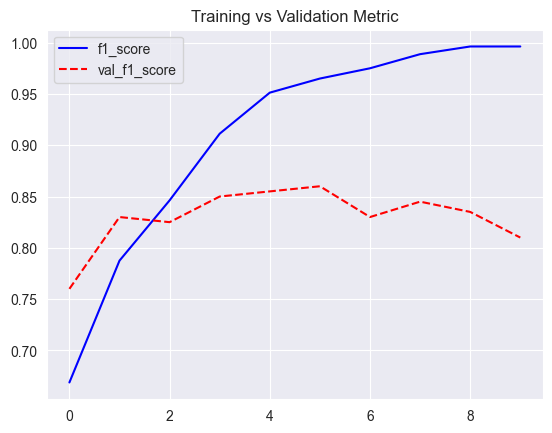

f1_score :  0.9962499737739563 val_f1_score :  0.8100000023841858


In [ ]:
plot_metric(history.history)

In [ ]:
y_pred = model.predict({'input_ids': token_ids_val, 'attention_mask': token_masks_val})
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred))

7/7 [==============================] - 1s 129ms/step
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.78      0.86      0.82       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200


In [ ]:
test_df["review_description"].tolist()[:5]

['buruk sekali pengiriman JNE ini . lemot pol .',
 'paket muter muter dan gak jalan jalan cs bilang di buat kan laporan laporan laporan TPI tidak ada hasil paket sya hilang ntah kemna jngn pakai jasa ini',
 'Expedisi paling buruk, pengiriman dari indramayu ke bandung sudah 10 hari belum sampai, kontak cs cuma dapat jawaban mohon di tunggu lagi proses pengecekan team terkait, expedisi macam apa ini🤬',
 'Nobody at office. Chat cs jne infonya kantor tutup. Padahal satap stay 24 jam 🤣',
 'Tracking resi tidak bisa cek detail aplikasi selalu restart ke menu awal terus, gimana ini udah paket lama app nya juga malah gak jelas']

In [ ]:
test_encodings = tokenizer(
    text=test_df["review_description"].tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

token_ids_test = np.array(test_encodings["input_ids"])
token_masks_test = np.array(test_encodings["attention_mask"])

In [ ]:
# get the predict probabilities
y_pred = model.predict({'input_ids': token_ids_test, 'attention_mask': token_masks_test})
y_pred

3388/3388 [==============================] - 544s 160ms/step


array([[1.3345576e-04, 9.9986649e-01],
       [9.9876803e-01, 1.2319649e-03],
       [9.9916267e-01, 8.3735044e-04],
       ...,
       [8.0775149e-05, 9.9991918e-01],
       [6.4442946e-05, 9.9993551e-01],
       [9.9904603e-01, 9.5395884e-04]], dtype=float32)

In [ ]:
# argmax if the probability is more than 0.85 else NaN
y_pred_confident = []
for prob_negative, prob_positive in y_pred:
    if prob_negative > 0.85:
        y_pred_confident.append(0)
    elif prob_positive > 0.85:
        y_pred_confident.append(1)
    else:
        y_pred_confident.append(np.nan)
y_pred_confident[:10]

[1, 0, 0, 1, nan, 1, 0, 0, 0, 0]

In [ ]:
test_df["sentimen"] = y_pred_confident
test_df.head()

,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition,sentimen
1,Google Play,afee4dfd-d2d1-4e5f-a9d8-f9f1f0e1ac01,marifat dieyah,NaN,buruk sekali pengiriman JNE ini . lemot pol .,1,0,2023-10-03 07:17:46,NaN,NaN,NaN,id,id,JNE,1.0
2,Google Play,8f2ab06b-4f0d-4a82-a6c2-4dba644472ef,nur sela,NaN,paket muter muter dan gak jalan jalan cs bilan...,1,0,2023-10-03 06:14:08,NaN,NaN,NaN,id,id,JNE,0.0
3,Google Play,6dc71aee-60c3-4955-8f7a-9e96962bda12,robby sobara,NaN,"Expedisi paling buruk, pengiriman dari indrama...",1,0,2023-10-03 05:15:55,NaN,NaN,1.2.6,id,id,JNE,0.0
4,Google Play,26fdb423-103f-41b1-bd8e-825ea3e8ddf0,William Aditya,NaN,Nobody at office. Chat cs jne infonya kantor t...,1,0,2023-10-03 04:42:36,NaN,NaN,2.3.9,id,id,JNE,1.0
6,Google Play,3e36286c-3d01-40a2-a9eb-ff09b2278182,TSG Official,NaN,Tracking resi tidak bisa cek detail aplikasi s...,1,0,2023-10-02 21:57:02,NaN,NaN,1.2.6,id,id,JNE,NaN


In [ ]:
train_df = pd.concat([train_df, test_df])
train_df.reset_index(drop=True, inplace=True)
train_df.head()

,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition,sentimen
0,Google Play,2c6973de-c75a-405d-9b9e-e5bf233f200a,Bayu Winalas,NaN,Hingga ini masih baik-baik aja 🥰🥰🥰,5,0,2021-09-02 03:36:26,NaN,NaN,3.13.1,id,id,J&T,1.0
1,Google Play,94fde3c7-4a37-4c92-875c-2f33d585f490,Wahyono 345,NaN,"Terima kasih JNE,selama ini selalu pakai jasa ...",5,1,2020-12-14 14:38:40,NaN,NaN,1.1.14,id,id,JNE,1.0
2,Google Play,31927262-6bd2-4ec5-abe5-757dc7df9a7e,Pengguna Google,NaN,ok lah bisa ngebantu,5,0,2019-03-12 15:29:01,NaN,NaN,3.1.1,id,id,J&T,1.0
3,Google Play,9f71ba44-d15c-438b-b3d0-22f861137f03,Pengguna Google,NaN,langganan,5,0,2019-02-28 00:50:52,NaN,NaN,3.1.1,id,id,J&T,1.0
4,Google Play,b409cdd4-1998-4d48-a486-8a5846e446f4,Pengguna Google,NaN,T O P BGT . . Pengiriman super cepat bgt. .suk...,5,0,2016-05-04 12:17:49,NaN,NaN,NaN,id,id,J&T,1.0


In [ ]:
test_df = train_df[train_df["sentimen"].isna()]
train_df = train_df[~train_df["sentimen"].isna()]
test_df.shape, train_df.shape

((8892, 15), (100503, 15))

In [ ]:
train_df.to_csv("scrape_dataset/train_iter2.csv", index=False)
test_df.to_csv("scrape_dataset/test_iter2.csv", index=False)

## Iter 2

In [ ]:
train_df = pd.read_csv("scrape_dataset/train_iter2.csv")
test_df = pd.read_csv("scrape_dataset/test_iter2.csv")

/usr/local/lib/python3.8/dist-packages/IPython/core/interactiveshell.py:3172: DtypeWarning: Columns (8,9) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [ ]:
X = train_df['review_description'].values
y = np.array(train_df["sentimen"])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

MAX_LENGTH = 128

train_encodings = tokenizer(
    text=X_train.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

val_encodings = tokenizer(
    text=X_val.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

token_ids_train = np.array(train_encodings["input_ids"])
token_masks_train = np.array(train_encodings["attention_mask"])
token_ids_val = np.array(val_encodings["input_ids"])
token_masks_val = np.array(val_encodings["attention_mask"])

In [ ]:
bert_model = TFBertModel.from_pretrained(MODEL, from_pt=True)

weight_initializer = tf.keras.initializers.GlorotNormal(seed=42)

input_ids = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="input_ids")
input_mask = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="attention_mask")

embeddings = bert_model(input_ids, attention_mask=input_mask)[0]  # 0 = last hidden state, 1 = poller_output
out = tf.keras.layers.GlobalMaxPool1D()(embeddings)
out = Dense(128, activation='relu', kernel_initializer = weight_initializer)(out)
out = tf.keras.layers.Dropout(0.1)(out)
out = Dense(32, activation='relu', kernel_initializer = weight_initializer)(out)

y = Dense(2, activation='softmax', kernel_initializer=weight_initializer)(out)

model = tf.keras.Model(inputs=[input_ids, input_mask], outputs=y)
model.layers[2].trainable = True

optimizer = Adam(
    learning_rate=5e-05,  # HF recommendation
    epsilon=1e-08,
    decay=0.01,
    clipnorm=1.0
)
loss = CategoricalCrossentropy()
metric = f1_score
# metric = CategoricalAccuracy('balanced_accuracy')

model.compile(
    optimizer=optimizer,
    loss=loss,
    # loss="categorical_crossentropy",
    metrics=metric
)

with tf.device('/device:GPU:0'):
    history = model.fit(
        x={'input_ids': token_ids_train, 'attention_mask': token_masks_train},
        y=to_categorical(y_train),
        validation_data=({'input_ids': token_ids_val, 'attention_mask': token_masks_val},
                         to_categorical(y_val)),
        epochs=10,
        batch_size=8,
    )

You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.9.intermediate.dense.weight', 'roberta.encoder.layer.1.attention.self.value.bias', 'roberta.encoder.layer.0.attention.self.query.bias', 'roberta.encoder.layer.0.intermediate.dense.bias', 'roberta.encoder.layer.2.attention.self.value.weight', 'roberta.encoder.layer.10.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.self.value.weight', 'roberta.encoder.layer.6.attention.self.key.weight', 'roberta.embeddings.position_embeddings.weight', 'roberta.encoder.layer.10.attention.self.value.bias', 'roberta.encoder.layer.5.attention.self.query.weight', 'roberta.encoder.layer.2.output.dense.weight', 'roberta.encoder.layer.8.attention.self.value.weight', 'robe

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Epoch 1/10
10051/10051 [==============================] - 639s 62ms/step - loss: 0.1910 - f1_score: 0.9264 - val_loss: 0.1489 - val_f1_score: 0.9469
Epoch 2/10
10051/10051 [==============================] - 615s 61ms/step - loss: 0.1500 - f1_score: 0.9449 - 

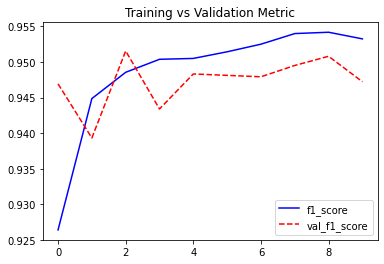

f1_score :  0.9532509446144104 val_f1_score :  0.9472244381904602


In [ ]:
plot_metric(history.history)

In [ ]:
y_pred = model.predict({'input_ids': token_ids_val, 'attention_mask': token_masks_val})
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96     12495
         1.0       0.98      0.88      0.93      7606

    accuracy                           0.95     20101
   macro avg       0.96      0.93      0.94     20101
weighted avg       0.95      0.95      0.95     20101



In [ ]:
test_encodings = tokenizer(
    text=test_df["review_description"].tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

token_ids_test = np.array(test_encodings["input_ids"])
token_masks_test = np.array(test_encodings["attention_mask"])

In [ ]:
# get the predict probabilities
y_pred = model.predict({'input_ids': token_ids_test, 'attention_mask': token_masks_test})

# argmax if the probability is more than 0.85 else NaN
y_pred_confident = []
for prob_negative, prob_positive in y_pred:
    if prob_negative > 0.85:
        y_pred_confident.append(0)
    elif prob_positive > 0.85:
        y_pred_confident.append(1)
    else:
        y_pred_confident.append(np.nan)
y_pred_confident[:10]

[0, 0, 0, 0, 0, 0, 1, 0, nan, 1]

In [ ]:
test_df["sentimen"] = y_pred_confident

train_df = pd.concat([train_df, test_df])
train_df.reset_index(drop=True, inplace=True)

test_df = train_df[train_df["sentimen"].isna()]
train_df = train_df[~train_df["sentimen"].isna()]

print(test_df.shape, train_df.shape)
train_df.head()

(1617, 15) (107778, 15)


,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition,sentimen
0,Google Play,2c6973de-c75a-405d-9b9e-e5bf233f200a,Bayu Winalas,NaN,Hingga ini masih baik-baik aja 🥰🥰🥰,5,0,2021-09-02 03:36:26,NaN,NaN,3.13.1,id,id,J&T,1.0
1,Google Play,94fde3c7-4a37-4c92-875c-2f33d585f490,Wahyono 345,NaN,"Terima kasih JNE,selama ini selalu pakai jasa ...",5,1,2020-12-14 14:38:40,NaN,NaN,1.1.14,id,id,JNE,1.0
2,Google Play,31927262-6bd2-4ec5-abe5-757dc7df9a7e,Pengguna Google,NaN,ok lah bisa ngebantu,5,0,2019-03-12 15:29:01,NaN,NaN,3.1.1,id,id,J&T,1.0
3,Google Play,9f71ba44-d15c-438b-b3d0-22f861137f03,Pengguna Google,NaN,langganan,5,0,2019-02-28 00:50:52,NaN,NaN,3.1.1,id,id,J&T,1.0
4,Google Play,b409cdd4-1998-4d48-a486-8a5846e446f4,Pengguna Google,NaN,T O P BGT . . Pengiriman super cepat bgt. .suk...,5,0,2016-05-04 12:17:49,NaN,NaN,NaN,id,id,J&T,1.0


In [ ]:
train_df.to_csv("scrape_dataset/train_iter3.csv", index=False)
test_df.to_csv("scrape_dataset/test_iter3.csv", index=False)

In [ ]:
train_df = pd.read_csv("scrape_dataset/train_iter3.csv")
test_df = pd.read_csv("scrape_dataset/test_iter3.csv")

In [ ]:
train_df.sentimen.value_counts()

0.0    69023
1.0    38755
Name: sentimen, dtype: int64

In [ ]:
test_df.sentimen.isnull().sum()

1617

## Iter 3

In [ ]:
X = train_df['review_description'].values
y = np.array(train_df["sentimen"])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

MAX_LENGTH = 128

train_encodings = tokenizer(
    text=X_train.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

val_encodings = tokenizer(
    text=X_val.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

token_ids_train = np.array(train_encodings["input_ids"])
token_masks_train = np.array(train_encodings["attention_mask"])
token_ids_val = np.array(val_encodings["input_ids"])
token_masks_val = np.array(val_encodings["attention_mask"])

In [ ]:
bert_model = TFBertModel.from_pretrained(MODEL, from_pt=True)

weight_initializer = tf.keras.initializers.GlorotNormal(seed=42)

input_ids = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="input_ids")
input_mask = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="attention_mask")

embeddings = bert_model(input_ids, attention_mask=input_mask)[0]  # 0 = last hidden state, 1 = poller_output
out = tf.keras.layers.GlobalMaxPool1D()(embeddings)
out = Dense(128, activation='relu', kernel_initializer = weight_initializer)(out)
out = tf.keras.layers.Dropout(0.1)(out)
out = Dense(32, activation='relu', kernel_initializer = weight_initializer)(out)

y = Dense(2, activation='softmax', kernel_initializer=weight_initializer)(out)

model = tf.keras.Model(inputs=[input_ids, input_mask], outputs=y)
model.layers[2].trainable = True

optimizer = Adam(
    learning_rate=5e-05,  # HF recommendation
    epsilon=1e-08,
    decay=0.01,
    clipnorm=1.0
)
loss = CategoricalCrossentropy()
metric = f1_score
# metric = CategoricalAccuracy('balanced_accuracy')

model.compile(
    optimizer=optimizer,
    loss=loss,
    # loss="categorical_crossentropy",
    metrics=metric
)

with tf.device('/device:GPU:0'):
    history = model.fit(
        x={'input_ids': token_ids_train, 'attention_mask': token_masks_train},
        y=to_categorical(y_train),
        validation_data=({'input_ids': token_ids_val, 'attention_mask': token_masks_val},
                         to_categorical(y_val)),
        epochs=5,
        batch_size=8,
    )

You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.9.intermediate.dense.weight', 'roberta.encoder.layer.1.attention.self.value.bias', 'roberta.encoder.layer.0.attention.self.query.bias', 'roberta.encoder.layer.0.intermediate.dense.bias', 'roberta.encoder.layer.2.attention.self.value.weight', 'roberta.encoder.layer.10.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.self.value.weight', 'roberta.encoder.layer.6.attention.self.key.weight', 'roberta.embeddings.position_embeddings.weight', 'roberta.encoder.layer.10.attention.self.value.bias', 'roberta.encoder.layer.5.attention.self.query.weight', 'roberta.encoder.layer.2.output.dense.weight', 'roberta.encoder.layer.8.attention.self.value.weight', 'robe

Epoch 1/5
10778/10778 [==============================] - 668s 61ms/step - loss: 0.2087 - f1_score: 0.9198 - val_loss: 0.1533 - val_f1_score: 0.9413
Epoch 2/5
10778/10778 [==============================] - 650s 60ms/step - loss: 0.1689 - f1_score: 0.9368 - val_loss: 0.1669 - val_f1_score: 0.9415
Epoch 3/5
10778/10778 [==============================] - 647s 60ms/step - loss: 0.1619 - f1_score: 0.9399 - val_loss: 0.1531 - val_f1_score: 0.9447
Epoch 4/5
10778/10778 [==============================] - 647s 60ms/step - loss: 0.1592 - f1_score: 0.9421 - val_loss: 0.1502 - val_f1_score: 0.9474
Epoch 5/5
10778/10778 [==============================] - 649s 60ms/step - loss: 0.1570 - f1_score: 0.9434 - val_loss: 0.1468 - val_f1_score: 0.9480


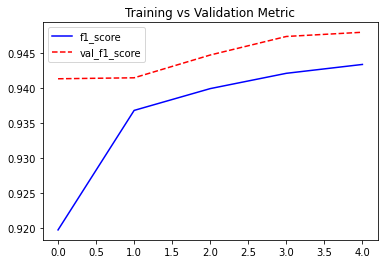

f1_score :  0.9433684349060059 val_f1_score :  0.9479591846466064


In [ ]:
plot_metric(history.history)

In [ ]:
y_pred = model.predict({'input_ids': token_ids_val, 'attention_mask': token_masks_val})
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96     13805
         1.0       0.95      0.90      0.93      7751

    accuracy                           0.95     21556
   macro avg       0.95      0.94      0.94     21556
weighted avg       0.95      0.95      0.95     21556



In [ ]:
test_encodings = tokenizer(
    text=test_df["review_description"].tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    # return_tensors='pt',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

token_ids_test = np.array(test_encodings["input_ids"])
token_masks_test = np.array(test_encodings["attention_mask"])

In [ ]:
# get the predict probabilities
y_pred = model.predict({'input_ids': token_ids_test, 'attention_mask': token_masks_test})

test_df["sentimen"] = y_pred

train_df = pd.concat([train_df, test_df])
train_df.reset_index(drop=True, inplace=True)

test_df = train_df[train_df["sentimen"].isna()]
train_df = train_df[~train_df["sentimen"].isna()]

print(test_df.shape, train_df.shape)
train_df.head()

(0, 15) (109395, 15)


,source,review_id,user_name,review_title,review_description,rating,thumbs_up,review_date,developer_response,developer_response_date,appVersion,laguage_code,country_code,expedition,sentimen
0,Google Play,2c6973de-c75a-405d-9b9e-e5bf233f200a,Bayu Winalas,NaN,Hingga ini masih baik-baik aja 🥰🥰🥰,5,0,2021-09-02 03:36:26,NaN,NaN,3.13.1,id,id,J&T,1.0
1,Google Play,94fde3c7-4a37-4c92-875c-2f33d585f490,Wahyono 345,NaN,"Terima kasih JNE,selama ini selalu pakai jasa ...",5,1,2020-12-14 14:38:40,NaN,NaN,1.1.14,id,id,JNE,1.0
2,Google Play,31927262-6bd2-4ec5-abe5-757dc7df9a7e,Pengguna Google,NaN,ok lah bisa ngebantu,5,0,2019-03-12 15:29:01,NaN,NaN,3.1.1,id,id,J&T,1.0
3,Google Play,9f71ba44-d15c-438b-b3d0-22f861137f03,Pengguna Google,NaN,langganan,5,0,2019-02-28 00:50:52,NaN,NaN,3.1.1,id,id,J&T,1.0
4,Google Play,b409cdd4-1998-4d48-a486-8a5846e446f4,Pengguna Google,NaN,T O P BGT . . Pengiriman super cepat bgt. .suk...,5,0,2016-05-04 12:17:49,NaN,NaN,NaN,id,id,J&T,1.0


In [ ]:
train_df.to_csv("scrape_dataset/train_iter4.csv", index=False)